In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [28]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label       = test
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


ntc_label       = non-targeting
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


'NTC'

In [32]:
data = sc.read_h5ad("../../datasets/gbm/top100_cripsri_gbm.h5ad")
data.obs.dose = data.obs.dose.astype(str)

slk.configs.set_config('untreated_label', 'untreated')
slk.pp.slk_prepare_data(data, pert_key="gene_id", ntc_label="NTC", treatment_key='dose', untreated_label='0.0', inplace=True)

AnnData object with n_obs × n_vars = 19923 × 5066
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster', 'pert'
    var: 'features', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [35]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 93/93 [00:01<00:00, 58.35it/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, 
                            batch_size=4096,
                             num_workers=0, 
                             device=device, 
                             use_conditions=True
                             )

In [ ]:
slk.tl.save_results(results, '../../results/gbm_cripsri.pth')

In [53]:
model = slk.tl.load_results('../../results/crispri_model_20251105_103826.pth')

In [87]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [ ]:
data.uns['results']

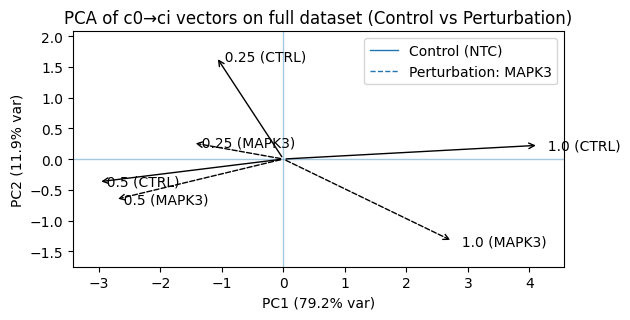

PC1/PC2 (Control):
           0.25: (-1.0888, 1.6609)
            0.5: (-3.0054, -0.3705)
            1.0: (4.1499, 0.2235)

PC1/PC2 (MAPK3):
           0.25: (-1.4723, 0.2632)
            0.5: (-2.7329, -0.6578)
            1.0: (2.7552, -1.3353)


In [92]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------ fetch & normalize shapes ------------------------
# Control/null: either (C' x D) where C' may be C-1 (untreated dropped) or C
cfs_null = np.asarray(data.uns['results']['cfs_null'], dtype=float)       # (C' x D)
cfs_perts = np.asarray(data.uns['results']['cfs_perts'], dtype=float)     # (P x C' x D)
conds_all = list(data.uns['results']['conds'])                             # length C (with untreated at index 0)
pert_names = list(data.uns['results']['perts'])                            # length P (strings)

# figure out which condition labels align rows of cfs_* (handles C' = C-1 vs C)
C_full = len(conds_all)
Cprime, D = cfs_null.shape
if Cprime == C_full - 1:
    cond_labels = conds_all[1:1+Cprime]   # skip untreated
else:
    cond_labels = conds_all[:Cprime]      # already includes whatever set was used

P = cfs_perts.shape[0]
assert cfs_perts.shape[1] == Cprime and cfs_perts.shape[2] == D, "cfs_perts must be (P x C' x D)"

# ------------------------ build full PCA matrix: P*2*C' x D ------------------------
# For each perturbation, include BOTH the control (cfs_null) and that perturbation's vectors.
# Control gets tiled P times so the dataset is balanced per perturbation.
X_ctrl_tiled = np.tile(cfs_null[None, :, :], (P, 1, 1))     # (P x C' x D)
X_perts_flat = cfs_perts.reshape(P * Cprime, D)             # (P*C' x D)
X_ctrl_flat  = X_ctrl_tiled.reshape(P * Cprime, D)          # (P*C' x D)

X_all = np.vstack([X_ctrl_flat, X_perts_flat])              # (P*2*C' x D)

# ------------------------ PCA (covariance eigendecomposition) ------------------------
Xc = X_all - X_all.mean(axis=0, keepdims=True)
Cov = np.cov(Xc, rowvar=False, bias=False)                  # (D x D)
eigvals, eigvecs = np.linalg.eigh(Cov)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
scores_all = Xc @ eigvecs                                   # (P*2*C' x D)
pc12_all = scores_all[:, :2]
var_exp = eigvals / eigvals.sum() if eigvals.sum() != 0 else np.zeros_like(eigvals)

# ------------------------ choose perturbation to display ------------------------
# pick by name or by index
pert_name_or_idx = "MAPK3"   


if isinstance(pert_name_or_idx, (int, np.integer)):
    assert 0 <= pert_name_or_idx < P, "pert index out of range"
    p_idx = int(pert_name_or_idx)
    pert_label = str(pert_names[p_idx])
else:
    assert pert_name_or_idx in pert_names, f"{pert_name_or_idx} not in results['perts']"
    p_idx = pert_names.index(pert_name_or_idx)
    pert_label = pert_name_or_idx

# indices inside the big stacked matrix:
# ctrl block:         rows [0 .. P*C'-1], where this pert's control rows are [p_idx*C' .. (p_idx+1)*C' - 1]
# perturbation block: rows [P*C' .. P*2*C' -1], this pert's rows are [P*C' + p_idx*C' .. P*C' + (p_idx+1)*C' - 1]
ctrl_start = p_idx * Cprime
ctrl_end   = (p_idx + 1) * Cprime
pert_start = P * Cprime + p_idx * Cprime
pert_end   = P * Cprime + (p_idx + 1) * Cprime

pc_ctrl = pc12_all[ctrl_start:ctrl_end, :]   # (C' x 2)
pc_pert = pc12_all[pert_start:pert_end, :]   # (C' x 2)

# ------------------------ plot arrows (Control vs chosen Pert) ------------------------
fig, ax = plt.subplots()

# axes through origin
ax.axhline(0, linewidth=1, alpha=0.4)
ax.axvline(0, linewidth=1, alpha=0.4)

# control arrows (solid)
for (x, y), name in zip(pc_ctrl, cond_labels):
    ax.annotate("", xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle="->", lw=1))
    ax.text(x, y, f"  {name} (CTRL)", ha="left", va="center")

# perturbation arrows (dashed)
for (x, y), name in zip(pc_pert, cond_labels):
    ax.annotate("", xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle="->", lw=1, linestyle="--"))
    ax.text(x, y, f"  {name} ({pert_label})", ha="left", va="center")

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% var)" if len(var_exp) > 0 else "PC1")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% var)" if len(var_exp) > 1 else "PC2")
ax.set_title("PCA of c0→ci vectors on full dataset (Control vs Perturbation)")

# bounds include origin and arrow tips + padding
pc_pair = np.vstack([pc_ctrl, pc_pert])
if pc_pair.size:
    pad = 0.1 * np.max(np.abs(pc_pair))
    xmin = min(0.0, pc_pair[:, 0].min()) - pad
    xmax = max(0.0, pc_pair[:, 0].max()) + pad
    ymin = min(0.0, pc_pair[:, 1].min()) - pad
    ymax = max(0.0, pc_pair[:, 1].max()) + pad
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

ax.set_aspect("equal", adjustable="box")

# legend by style
legend_elems = [
    Line2D([0], [0], lw=1, linestyle='-',  label="Control (NTC)"),
    Line2D([0], [0], lw=1, linestyle='--', label=f"Perturbation: {pert_label}"),
]
ax.legend(handles=legend_elems, loc="best")

plt.tight_layout()
plt.show()

# (optional) print coordinates
print("PC1/PC2 (Control):")
for (x, y), name in zip(pc_ctrl, cond_labels):
    print(f"{name:>15s}: ({x:.4f}, {y:.4f})")
print(f"\nPC1/PC2 ({pert_label}):")
for (x, y), name in zip(pc_pert, cond_labels):
    print(f"{name:>15s}: ({x:.4f}, {y:.4f})")


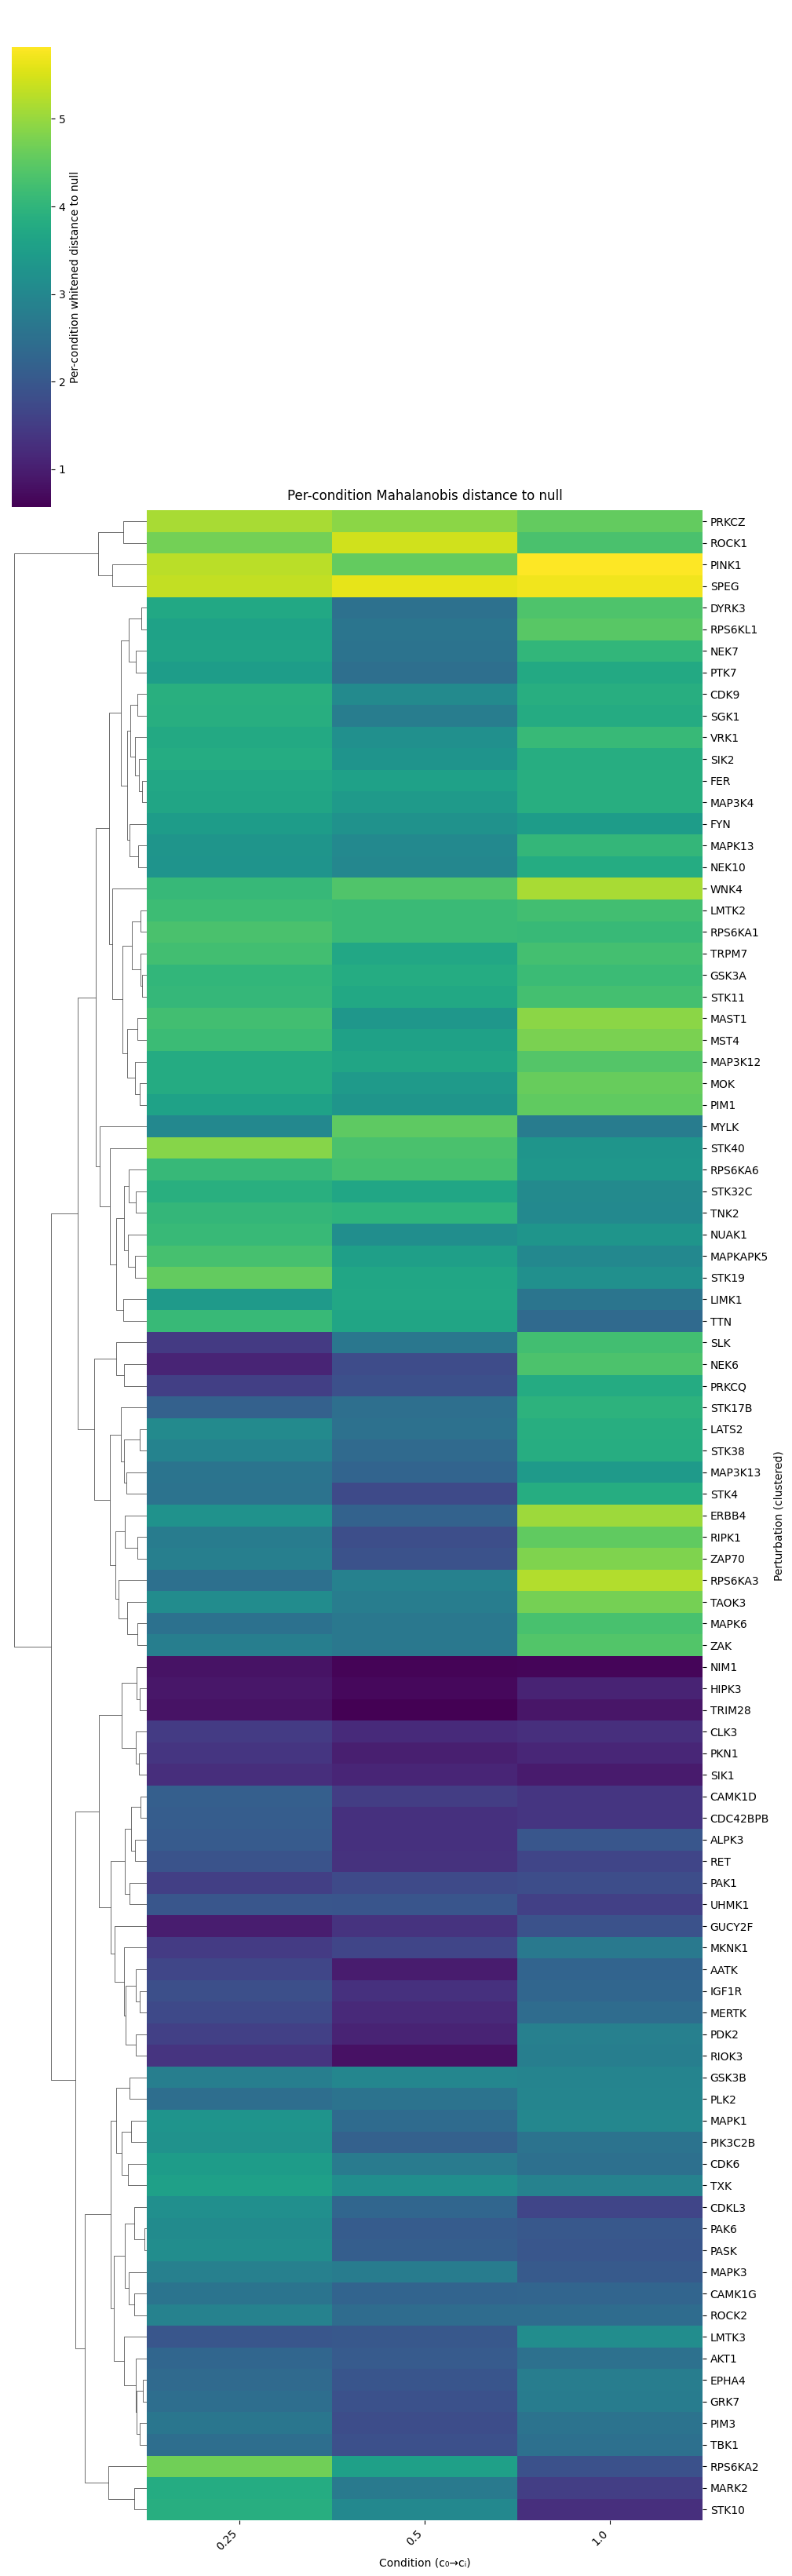

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- pull from .uns ---
cfs_null  = np.asarray(data.uns['results']['cfs_null'],  dtype=float)   # (C' x D)
cfs_perts = np.asarray(data.uns['results']['cfs_perts'], dtype=float)   # (P  x C' x D)
cond_names = list(data.uns['results']['conds'])                         # length C, 0 = untreated
pert_names = list(data.uns['results']['perts'])                         # length P

Cprime, D = cfs_null.shape
P = cfs_perts.shape[0]
col_labels = cond_names[1:1+Cprime] if Cprime == (len(cond_names)-1) else cond_names[:Cprime]

# --- per-condition Mahalanobis distances (each dose has its own Σ_i) ---
dists = np.zeros((P, Cprime), dtype=float)

# optional: try Ledoit-Wolf shrinkage if available
try:
    from sklearn.covariance import LedoitWolf
    use_lw = True
except Exception:
    use_lw = False

eps = 1e-12
for i in range(Cprime):
    # stack all vectors for this condition: (P+1) x D  [null + all perts]
    X_i = np.vstack([cfs_null[i][None, :], cfs_perts[:, i, :]])   # (P+1, D)
    Xc  = X_i - X_i.mean(axis=0, keepdims=True)

    # covariance for this condition
    if use_lw:
        Sigma_i = LedoitWolf().fit(Xc).covariance_
    else:
        # ridge-shrinkage if sklearn isn't available
        Sigma_i = np.cov(Xc, rowvar=False, bias=False)
        # shrink by a small fraction of trace to stabilize
        lam = 1e-3 * (np.trace(Sigma_i) / D if D > 0 else 1.0)
        Sigma_i = Sigma_i + lam * np.eye(D)

    # whitener W_i = Σ_i^{-1/2}
    e, U = np.linalg.eigh(Sigma_i)
    e = np.clip(e, eps, None)
    W_i = U @ np.diag(1.0 / np.sqrt(e)) @ U.T

    # differences to null for this condition (P x D)
    diff_i = cfs_perts[:, i, :] - cfs_null[i][None, :]
    # whitened distances
    dists[:, i] = np.linalg.norm(diff_i @ W_i, axis=1)

# --- clustermap (cluster rows only) ---
height = max(6, 0.35 * P)
g = sns.clustermap(
    dists,
    row_cluster=True, col_cluster=False,
    cmap="viridis", vmin=dists.min(), vmax=dists.max(),
    yticklabels=pert_names, xticklabels=col_labels,
    figsize=(10, height), cbar_kws={"label": "Per-condition whitened distance to null"}
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.ax_heatmap.set_xlabel("Condition (c₀→cᵢ)")
g.ax_heatmap.set_ylabel("Perturbation (clustered)")
g.ax_heatmap.set_title("Per-condition Mahalanobis distance to null", pad=10)
plt.show()


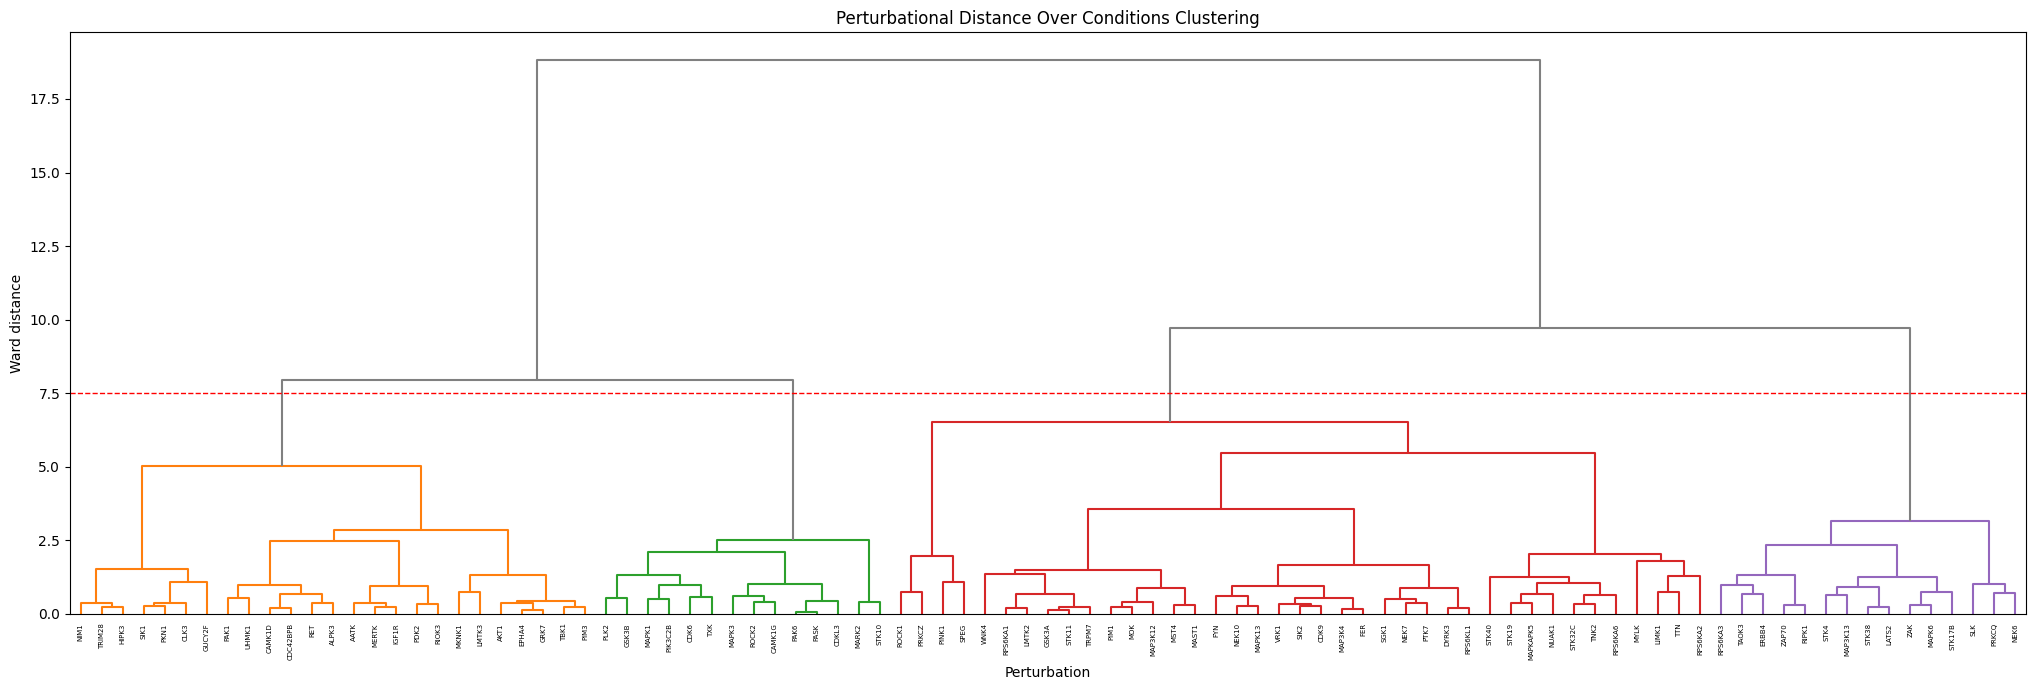

Cut at t = 7.5 produced 4 clusters.

Perturbation → group (head):
  perturbation  group
0         AATK      1
1         AKT1      1
2        ALPK3      1
3       CAMK1D      1
4       CAMK1G      2

Group mean distances (groups × conditions):
           0.25       0.5       1.0
group                              
1      1.724191  1.364527  1.959724
2      3.147269  2.539856  2.282308
3      4.024001  3.648393  3.917158
4      2.474381  2.294221  4.278833


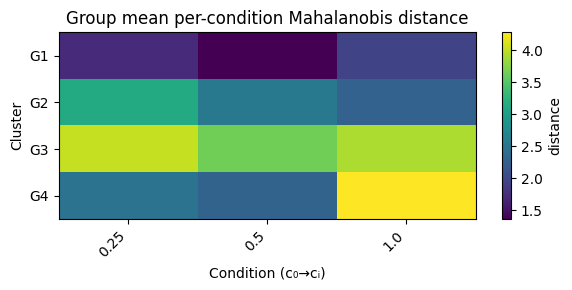

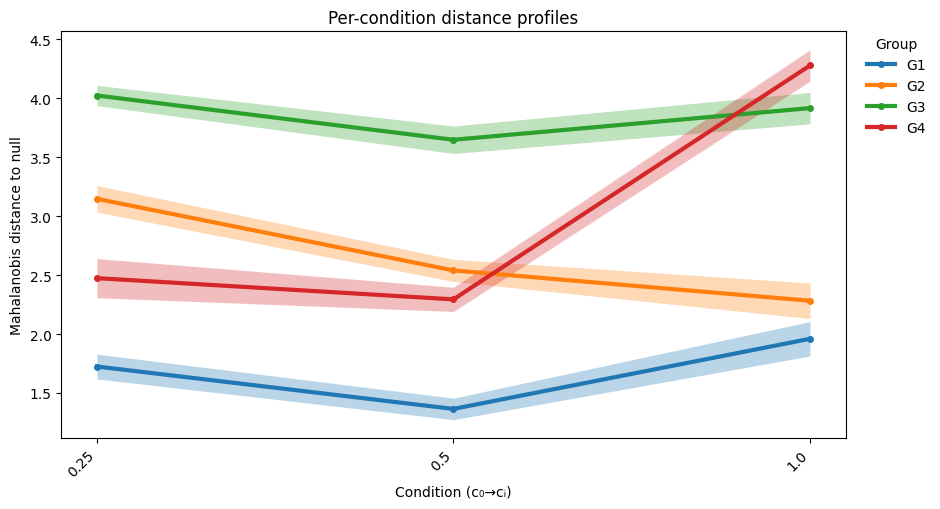

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

P, Cprime = dists.shape

# 1) Ward linkage on distance profiles
Z = linkage(dists, method="ward", optimal_ordering=True)

# === fixed distance cutoff ===
t = 7.5

# 2) Dendrogram (TOP orientation), a bit taller
fig, ax = plt.subplots(figsize=(max(10, 0.22 * P), 7))  # taller height
dn = dendrogram(
    Z,
    labels=pert_names,
    orientation="top",
    color_threshold=t,
    above_threshold_color="grey",
    ax=ax,
)
ax.axhline(t, color="red", linestyle="--", linewidth=1)
ax.set_title("Perturbational Distance Over Conditions Clustering")
ax.set_ylabel("Ward distance")
ax.set_xlabel("Perturbation")
plt.tight_layout()
plt.show()

# 3) Cut tree at threshold t → cluster labels
cluster_labels = fcluster(Z, t=t, criterion="distance")

# 4) Perturbation dataframe: mapping to groups
pert_df = pd.DataFrame({"perturbation": pert_names, "group": cluster_labels})

# 5) Group mean distances (groups × conditions)
group_means = (
    pd.DataFrame(dists, index=pert_names, columns=col_labels)
      .assign(group=cluster_labels)
      .groupby("group")[col_labels].mean()
)

# Order groups by first appearance in dendrogram leaves (same visual ordering)
leaf_order = dn["ivl"]
leaf_to_pos = {name: i for i, name in enumerate(leaf_order)}
first_pos = (
    pert_df.assign(pos=pert_df["perturbation"].map(leaf_to_pos))
           .groupby("group")["pos"].min()
           .sort_values()
)
group_means = group_means.loc[first_pos.index]
groups = list(group_means.index)

print(f"Cut at t = {t} produced {len(groups)} clusters.")
print("\nPerturbation → group (head):")
print(pert_df.head())

print("\nGroup mean distances (groups × conditions):")
print(group_means)

# 6) Heatmap of group means
fig, ax = plt.subplots(figsize=(6, max(3, 0.45 * len(groups))))
im = ax.imshow(group_means.values, aspect="auto", cmap="viridis")
ax.set_yticks(np.arange(group_means.shape[0]))
ax.set_yticklabels([f"G{g}" for g in group_means.index])
ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right")
ax.set_title("Group mean per-condition Mahalanobis distance")
ax.set_xlabel("Condition (c₀→cᵢ)")
ax.set_ylabel("Cluster")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("distance")
plt.tight_layout()
plt.show()

# 7) Line plot: mean ± 1 SEM per group (legend outside), improved colors & visibility
df = pd.DataFrame(dists, columns=col_labels)
df["group"] = cluster_labels

# stats
grp = df.groupby("group")[col_labels]
mean = grp.mean().reindex(groups)
std  = grp.std(ddof=1).reindex(groups)
n    = df.groupby("group").size().reindex(groups)
sem  = std.div(np.sqrt(n).replace(0, np.nan), axis=0).fillna(0.0)

# --- colorblind-friendly palette with strong contrast
# combine Tab10 + Set2 + Dark2 to get many distinct colors
def build_palette(G):
    base = []
    for name in ["tab10", "Set2", "Dark2"]:
        cmap = plt.get_cmap(name)
        base.extend([cmap(i) for i in range(cmap.N)])
    # de-duplicate while preserving order
    seen, uniq = set(), []
    for c in base:
        if c not in seen:
            uniq.append(c); seen.add(c)
    if G <= len(uniq):
        return uniq[:G]
    # fallback cycle if more groups than colors
    from itertools import cycle, islice
    return list(islice(cycle(uniq), G))

palette = build_palette(len(groups))
colors  = {g: palette[i] for i, g in enumerate(groups)}

x = np.arange(len(col_labels))
fig, ax = plt.subplots(figsize=(9.5, 5.2))

handles = []
for g in groups:
    mu = mean.loc[g].values
    se = sem.loc[g].values
    h, = ax.plot(x, mu, color=colors[g], linewidth=3.0, marker="o", markersize=4, label=f"G{g}")
    # make SEM band more visible
    ax.fill_between(x, mu - se, mu + se, color=colors[g], alpha=0.30, linewidth=0, zorder=h.get_zorder()-1)
    handles.append(h)

ax.set_xticks(x)
ax.set_xticklabels(col_labels, rotation=45, ha="right")
ax.set_xlabel("Condition (c₀→cᵢ)")
ax.set_ylabel("Mahalanobis distance to null")
ax.set_title("Per-condition distance profiles")


# Legend outside so it never blocks the lines
ax.legend(handles=handles, title="Group", frameon=False, ncol=1,
          bbox_to_anchor=(1.02, 1.0), loc="upper left", borderaxespad=0.0)

plt.tight_layout()
plt.show()


In [118]:
pert_df.to_csv('../../results/groups.csv')

/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


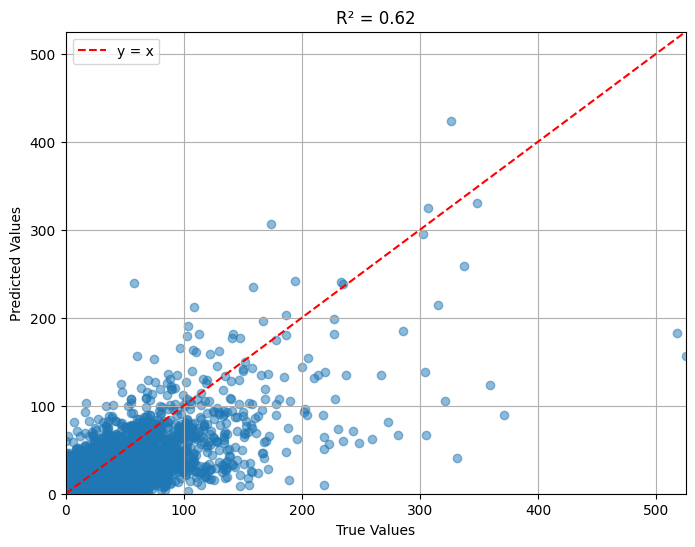

In [ ]:
slk.pl.plot_r2(data)

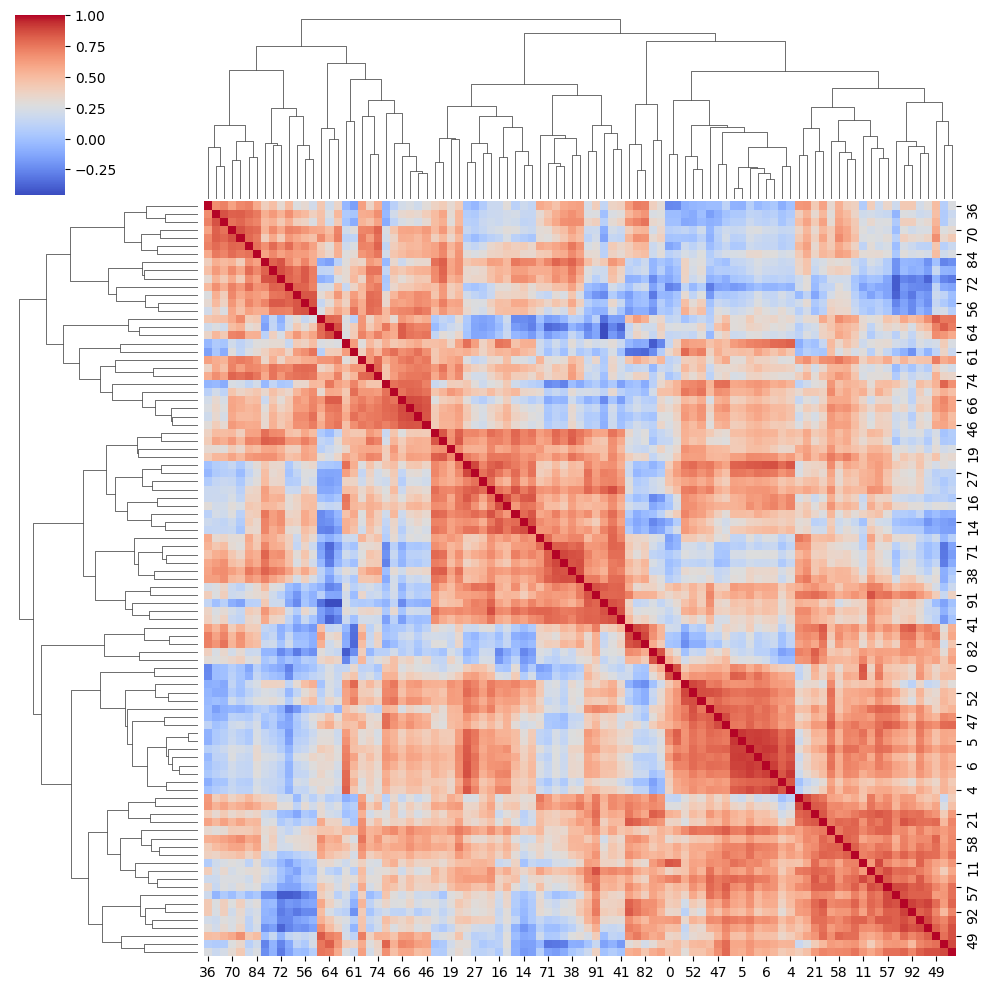

In [55]:
slk.pl.plot_corr(data)

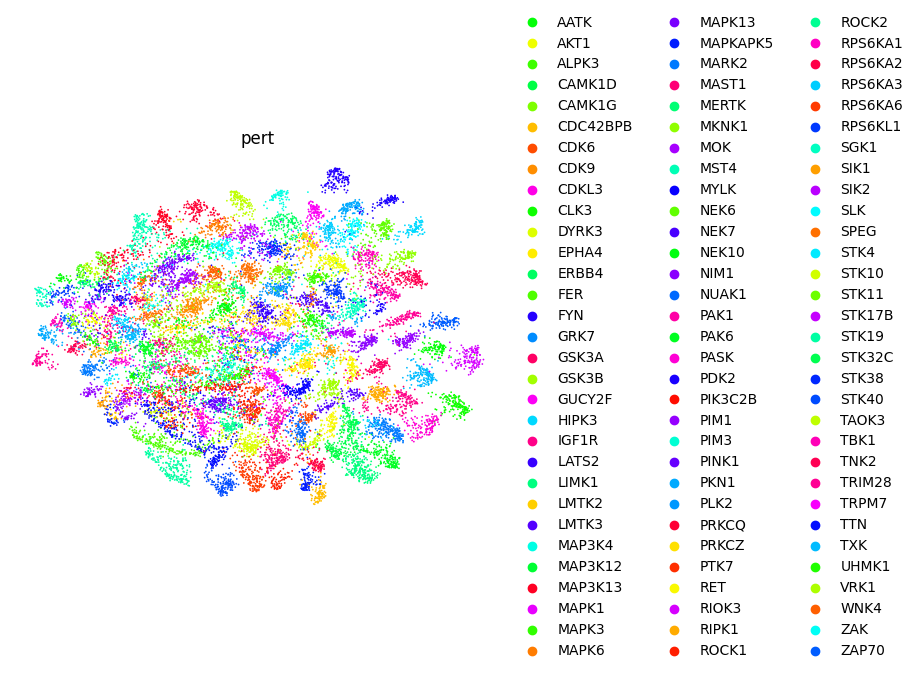

In [56]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [57]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.599  (p = 0.0e+00)
 Pearson  r = 0.610  (p = 0.0e+00)


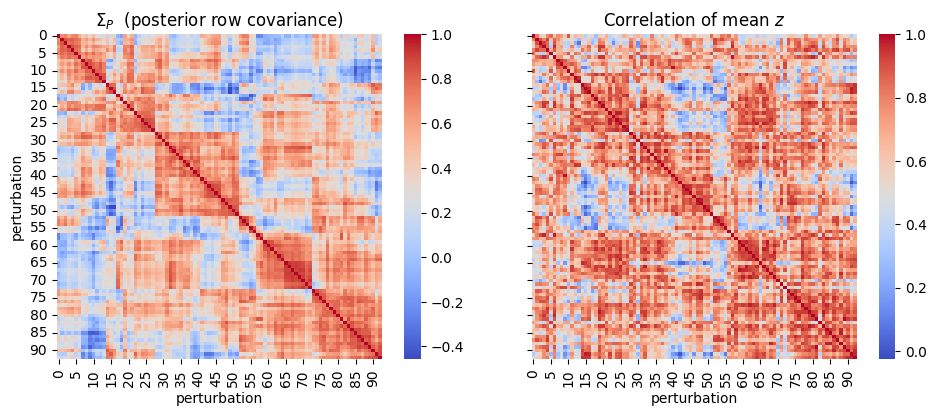

In [58]:
slk.pl.plot_zcorr(data)

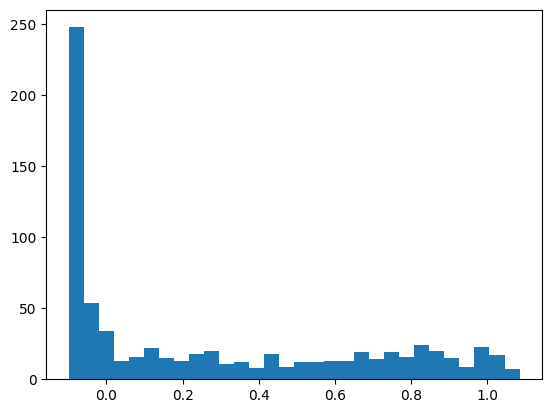

In [59]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

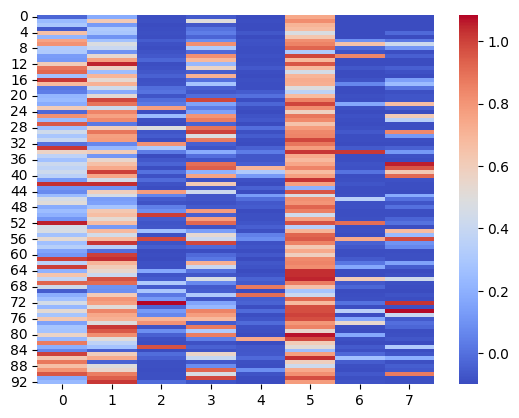

In [60]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [43]:

dataset = slk.tl.PerturbMatchingDataset(data)
all_genes = dataset.perturbation_dict.keys()

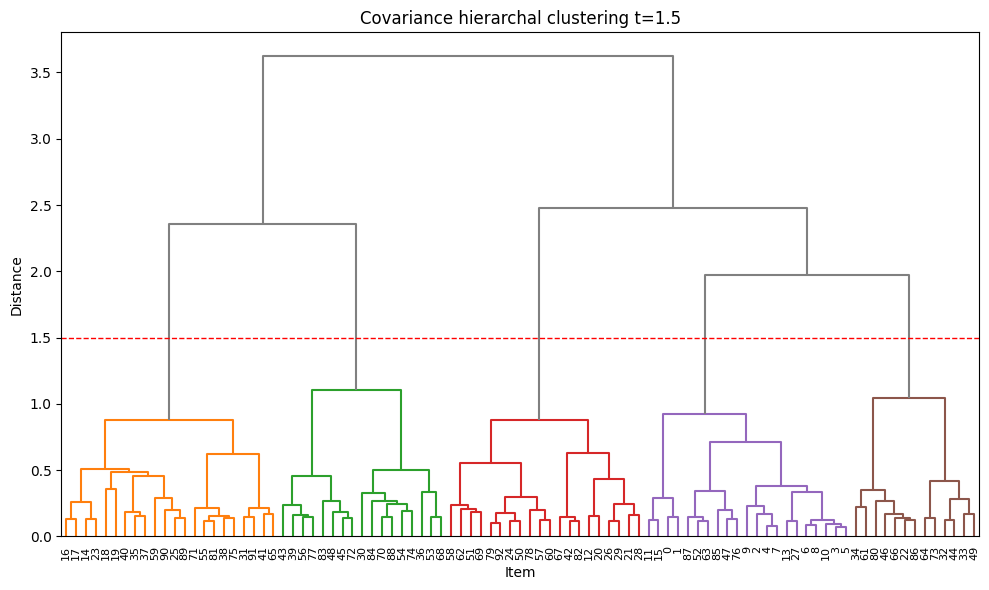

In [61]:
groups = slk.tl.cluster_rho(data, t=1.5, show=True)

In [62]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

NameError: name 'all_genes' is not defined

pert_group
1    5083
2    8163
3    2220
4    3044
Name: count, dtype: int64


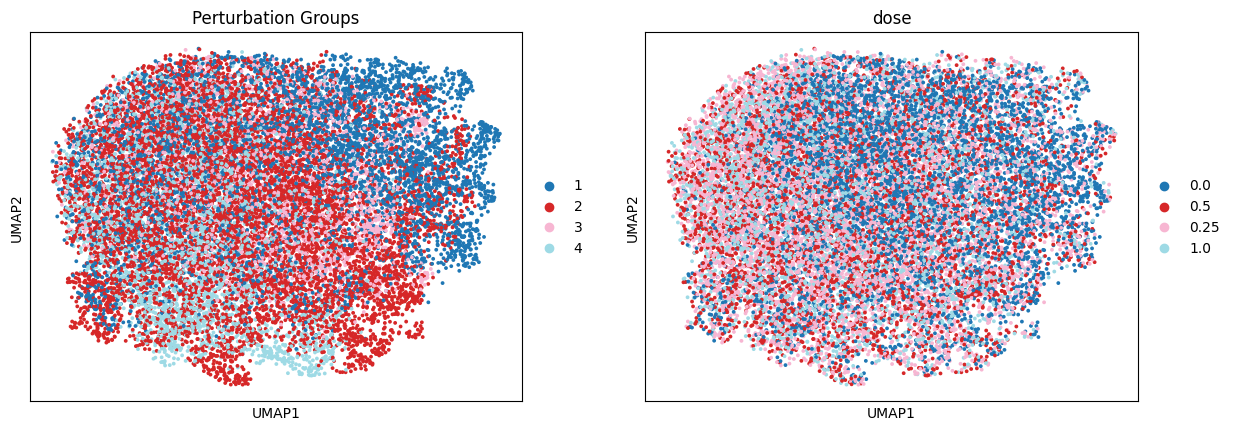

In [ ]:
# map perturbation -> group using named_groups (index=gene, column='group')
gene_to_group = named_groups['group'].to_dict()

# assign group to obs based on slk pert key
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
sub.obs['pert_group'] = sub.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(sub.obs['pert_group'].value_counts().sort_index())

sc.pl.umap(sub, color=['pert_group', 'dose'], title='Perturbation Groups', palette='tab20', size=30)

In [245]:
for i in sub.obs.pert_group.unique():
    print(i)
    print(sub[sub.obs.pert_group == i].obs['pert'].value_counts())

4
pert
ZNF281          163
TADA2B          126
EHMT1            86
TDP1             53
BLM              42
InterGenic16     37
MLLT1            36
UBP1             30
AEBP2            29
CHRAC1           26
BACH1            25
NR2C2            22
PBX1             21
CRAMP1L          19
TAF10            19
SARNP            19
MAFK             18
SS18             18
Name: count, dtype: int64
6
pert
ASF1A      114
USP22       67
FUBP3       60
ARNTL       46
ATF6B       41
ATXN7L3     40
ZGPAT       39
AJUBA       35
CBFB        34
MB21D1      31
RCBTB1      30
GTF3C5      28
TCFL5       28
ANKRD17     26
ZBTB2       26
TDRD3       24
DCLRE1A     24
FOSL2       21
SOX4        17
ZNF367      17
PBX3        15
RIF1        15
KLF3         9
Name: count, dtype: int64
1
pert
MED12      509
NR1H2       70
THAP7       37
MEF2D       31
E2F7        26
SETD8       25
HNRNPD      25
JUND        24
IKZF5       20
ZSCAN29     19
TCEA2       13
HMGN4       10
Name: count, dtype: int64
5
pert
ZNF460   

In [246]:
# Print gene symbols per group, one gene per line (no quotation marks)
grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())

for grp in sorted(grouped.index):
    print(f"Group {grp}:")
    for gene in grouped.loc[grp]:
        print(gene)
    print()

Group 1:
E2F7
HMGN4
HNRNPD
IKZF5
JUND
MED12
MEF2D
NR1H2
SETD8
TCEA2
THAP7
ZSCAN29

Group 2:
JMJD1C
ZIC2
ZNF280C

Group 3:
MAPK1
NBN
NR0B1
POGZ
REST
RNF2
RXRB
SFMBT1
SMARCD3
WBP11

Group 4:
AEBP2
BACH1
BLM
CHRAC1
CRAMP1L
EHMT1
InterGenic16
MAFK
MLLT1
NR2C2
PBX1
SARNP
SS18
TADA2B
TAF10
TDP1
UBP1
ZNF281

Group 5:
CTBP2
HDAC4
HMGB3
PLAGL1
RFC4
SMARCC1
ZFHX3
ZNF134
ZNF260
ZNF460

Group 6:
AJUBA
ANKRD17
ARNTL
ASF1A
ATF6B
ATXN7L3
CBFB
DCLRE1A
FOSL2
FUBP3
GTF3C5
KLF3
MB21D1
PBX3
RCBTB1
RIF1
SOX4
TCFL5
TDRD3
USP22
ZBTB2
ZGPAT
ZNF367



/var/tmp/ipykernel_2621841/2222304912.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())
